## **EDA Prices**

In this file we will load data from the database in order to analyze it.

**Datasbase connection**

In [1]:
import sqlite3
import pandas as pd

# Ruta a tu base de datos
db_path = r"C:\Users\HUGO\Desktop\Q8 - NORUEGA\TFG\tfg\NordPoool\data\thesis_database.db"

# Conexión
conn = sqlite3.connect(db_path)

print("Connected!")

Connected!


**Load data**

In [12]:
df_regions = pd.read_sql("SELECT * FROM Regions", conn)
df_regions.head()

,region_id,region_name
0,1,Baltic
1,2,CWE
2,3,Nordic


In [13]:
df_bidding_zones = pd.read_sql("SELECT * FROM BiddingZones", conn)
df_bidding_zones.head()

,zone_id,zone_code,country,region_id
0,1,EE,Estonia,1
1,2,LT,Lithuania,1
2,3,LV,Latvia,1
3,4,AT,Austria,2
4,5,BE,Belgium,2


In [35]:
df_prices = pd.read_sql("SELECT * FROM prices WHERE delivery_day >= '2020-01-01' AND delivery_day < '2021-01-01'", conn)
df_prices.head()

,price_id,zone_id,delivery_day,hour,price_value
0,1,1,2020-01-01,0,28.78
1,2,2,2020-01-01,0,28.78
2,3,3,2020-01-01,0,28.78
3,4,4,2020-01-01,0,41.88
4,5,5,2020-01-01,0,41.88


In [55]:
df_prices.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 175680 entries, 0 to 175679
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   price_id      175680 non-null  int64         
 1   zone_id       175680 non-null  int64         
 2   delivery_day  175680 non-null  datetime64[ns]
 3   hour          175680 non-null  int64         
 4   price_value   175680 non-null  float64       
 5   year          175680 non-null  int32         
dtypes: datetime64[ns](1), float64(1), int32(1), int64(3)
memory usage: 7.4 MB


## **1. Basic information about the data**

In [37]:
df_prices.columns

Index(['price_id', 'zone_id', 'delivery_day', 'hour', 'price_value'], dtype='object')

Overall information about the price:

In [47]:
price_volatility_by_area = (
    df_prices
    .merge(df_bidding_zones, on="zone_id", how="left")
    .query("country == 'Norway'")
    .groupby(["zone_id", "zone_code", "country"])["price_value"]
    .agg(
        median="median",
        std="std",
        min="min",
        max="max"
    )
    .reset_index()
)

price_volatility_by_area["range"] = price_volatility_by_area["max"] - price_volatility_by_area["min"]

price_volatility_by_area = price_volatility_by_area.sort_values(
    by="std",
    ascending=False
).reset_index(drop=True)

price_volatility_by_area

,zone_id,zone_code,country,median,std,min,max,range
0,12,NO1,Norway,6.960,8.276693,-1.73,99.92,101.65
1,13,NO2,Norway,6.950,8.261798,-1.73,99.92,101.65
2,16,NO5,Norway,6.855,7.905460,-0.09,99.92,100.01
3,14,NO3,Norway,7.500,6.918513,0.00,57.00,57.00
4,15,NO4,Norway,7.420,6.480879,0.00,57.00,57.00


**VOLATILITY**

<u> Bloxplot </u>

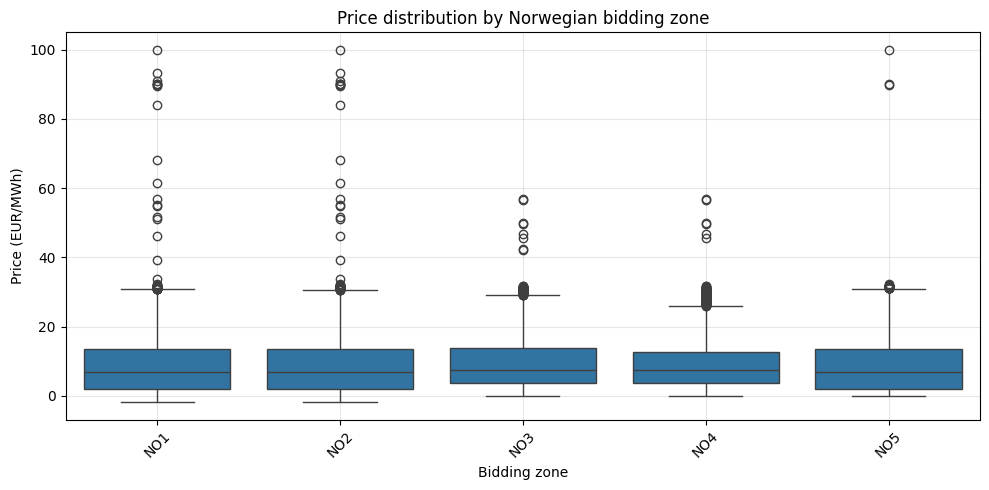

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter Norway zones
norway_zones = ["NO1", "NO2", "NO3", "NO4", "NO5"]

df_norway = df_prices.merge(
    df_bidding_zones[["zone_id", "zone_code", "country"]],
    on="zone_id",
    how="left"
)

df_norway = df_norway[df_norway["zone_code"].isin(norway_zones)].copy()

# Plot
plt.figure(figsize=(10, 5))
sns.boxplot(
    data=df_norway,
    x="zone_code",
    y="price_value"
)

plt.title("Price distribution by Norwegian bidding zone")
plt.xlabel("Bidding zone")
plt.ylabel("Price (EUR/MWh)")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

<u> Metrics </u>

In [67]:
import pandas as pd

# Compute statistics
volatility_stats = df_norway.groupby("zone_code")["price_value"].agg(
    count="count",
    mean="mean",
    median="median",
    std="std",
    min_value="min",
    max_value="max",
    q1=lambda x: x.quantile(0.25),
    q3=lambda x: x.quantile(0.75)
).reset_index()

# Additional metrics
volatility_stats["iqr"] = volatility_stats["q3"] - volatility_stats["q1"]
volatility_stats["price_range"] = volatility_stats["max_value"] - volatility_stats["min_value"]
volatility_stats["cv"] = volatility_stats["std"] / volatility_stats["mean"]

# Outliers and whiskers
outlier_results = []

for zone in norway_zones:
    zone_data = df_norway[df_norway["zone_code"] == zone]["price_value"]
    
    q1 = zone_data.quantile(0.25)
    q3 = zone_data.quantile(0.75)
    iqr = q3 - q1
    
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    
    # Values within the non-outlier range
    within_bounds = zone_data[(zone_data >= lower_bound) & (zone_data <= upper_bound)]
    
    # Real whiskers
    lower_whisker = within_bounds.min()
    upper_whisker = within_bounds.max()
    
    # Outliers
    outliers = zone_data[(zone_data < lower_bound) | (zone_data > upper_bound)]
    
    outlier_results.append({
        "zone_code": zone,
        "lower_bound": lower_bound,
        "upper_bound": upper_bound,
        "lower_whisker": lower_whisker,
        "upper_whisker": upper_whisker,
        "outliers_count": len(outliers),
        "outliers_pct": len(outliers) / len(zone_data) * 100
    })

outlier_results = pd.DataFrame(outlier_results)

# Merge
volatility_stats = volatility_stats.merge(outlier_results, on="zone_code", how="left")

# Clean table
volatility_stats = volatility_stats[
    [
        "zone_code",
        "mean",
        "median",
        "std",
        "cv",
        "q1",
        "q3",
        "iqr",
        "lower_bound",
        "upper_bound",
        "lower_whisker",
        "upper_whisker",
        "min_value",
        "max_value",
        "price_range",
        "outliers_count",
        "outliers_pct"
    ]
].round(3)

volatility_stats

,zone_code,mean,median,std,cv,q1,q3,iqr,lower_bound,upper_bound,lower_whisker,upper_whisker,min_value,max_value,price_range,outliers_count,outliers_pct
0,NO1,9.289,6.960,8.277,0.891,1.990,13.552,11.562,-15.354,30.896,-1.73,30.88,-1.73,99.92,101.65,74,0.842
1,NO2,9.291,6.950,8.262,0.889,2.130,13.552,11.422,-15.004,30.686,-1.73,30.67,-1.73,99.92,101.65,84,0.956
2,NO3,9.457,7.500,6.919,0.732,3.790,13.932,10.142,-11.424,29.146,0.00,29.11,0.00,57.00,57.00,81,0.922
3,NO4,8.877,7.420,6.481,0.730,3.698,12.630,8.933,-9.701,26.029,0.00,26.02,0.00,57.00,57.00,196,2.231
4,NO5,9.173,6.855,7.905,0.862,1.920,13.542,11.622,-15.514,30.976,-0.09,30.96,-0.09,99.92,100.01,50,0.569


<u> Volatility ranking </u>

Revisar

In [66]:
# Copy table
volatility_ranking = volatility_stats.copy()

# Rankings (higher = more volatile)
volatility_ranking["rank_std"] = volatility_ranking["std"].rank(ascending=False)
volatility_ranking["rank_iqr"] = volatility_ranking["iqr"].rank(ascending=False)
volatility_ranking["rank_range"] = volatility_ranking["price_range"].rank(ascending=False)
volatility_ranking["rank_outliers"] = volatility_ranking["outliers_pct"].rank(ascending=False)
volatility_ranking["rank_cv"] = volatility_ranking["cv"].rank(ascending=False)

# Final score (simple average)
volatility_ranking["volatility_score"] = volatility_ranking[
    ["rank_std", "rank_iqr", "rank_range", "rank_outliers", "rank_cv"]
].mean(axis=1)

# Sort (lower score = more volatile)
volatility_ranking = volatility_ranking.sort_values("volatility_score")

# Final table
volatility_ranking[
    [
        "zone_code",
        "std",
        "iqr",
        "price_range",
        "outliers_pct",
        "cv",
        "volatility_score"
    ]
].round(3)

,zone_code,std,iqr,price_range,outliers_pct,cv,volatility_score
0,NO1,8.277,11.562,101.65,0.842,0.891,1.9
1,NO2,8.262,11.422,101.65,0.956,0.889,2.1
4,NO5,7.905,11.622,100.01,0.569,0.862,3.0
2,NO3,6.919,10.142,57.00,0.922,0.732,3.9
3,NO4,6.481,8.933,57.00,2.231,0.730,4.1
